In [ ]:
!pip install -q scanpy leidenalg python-igraph scrublet

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white", figsize=(5, 5))
sc.logging.print_header()

adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(adata)

adata.var["mt"]   = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4, multi_panel=True,
)
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

sc.pp.scrublet(adata)
print("Predicted doublets:", int(adata.obs["predicted_doublet"].sum()))
adata = adata[~adata.obs["predicted_doublet"], :].copy()

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()

In [ ]:
s_genes = ["MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2",
           "MCM6","CDCA7","DTL","PRIM1","UHRF1","HELLS","RFC2","NASP",
           "RAD51AP1","GMNN","WDR76","SLBP","CCNE2","UBR7","POLD3","MSH2",
           "ATAD2","RAD51","RRM2","CDC45","CDC6","EXO1","TIPIN","DSCC1",
           "BLM","CASP8AP2","USP1","CLSPN","POLA1","CHAF1B","E2F8"]
g2m_genes = ["HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80",
             "CKS2","NUF2","CKS1B","MKI67","TMPO","CENPF","TACC3","SMC4",
             "CCNB2","CKAP2L","CKAP2","AURKB","BUB1","KIF11","ANP32E",
             "TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","CDC20","TTK",
             "CDC25C","KIF2C","RANGAP1","NCAPD2","DLGAP5","CDCA2","CDCA8",
             "ECT2","KIF23","HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5",
             "CENPE","NEK2","G2E3","CBX5","CENPA"]
s_genes   = [g for g in s_genes   if g in adata.var_names]
g2m_genes = [g for g in g2m_genes if g in adata.var_names]
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.tsne(adata, n_pcs=40)

In [ ]:
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="Leiden clusters")
sc.pl.tsne(adata, color="leiden", legend_loc="on data", title="t-SNE clusters")

sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

result   = adata.uns["rank_genes_groups"]
groups   = result["names"].dtype.names
top_df   = pd.DataFrame({g: result["names"][g][:10] for g in groups})
print("\nTop 10 markers per cluster:\n", top_df)

marker_genes = {
    "B-cell":           ["CD79A", "MS4A1"],
    "CD8 T-cell":       ["CD8A", "CD8B"],
    "CD4 T-cell":       ["IL7R", "CD4"],
    "NK":               ["GNLY", "NKG7"],
    "CD14 Monocyte":    ["CD14", "LYZ"],
    "FCGR3A Monocyte":  ["FCGR3A", "MS4A7"],
    "Dendritic":        ["FCER1A", "CST3"],
    "Megakaryocyte":    ["PPBP"],
}
sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")
sc.pl.stacked_violin(adata, marker_genes, groupby="leiden", swap_axes=True)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


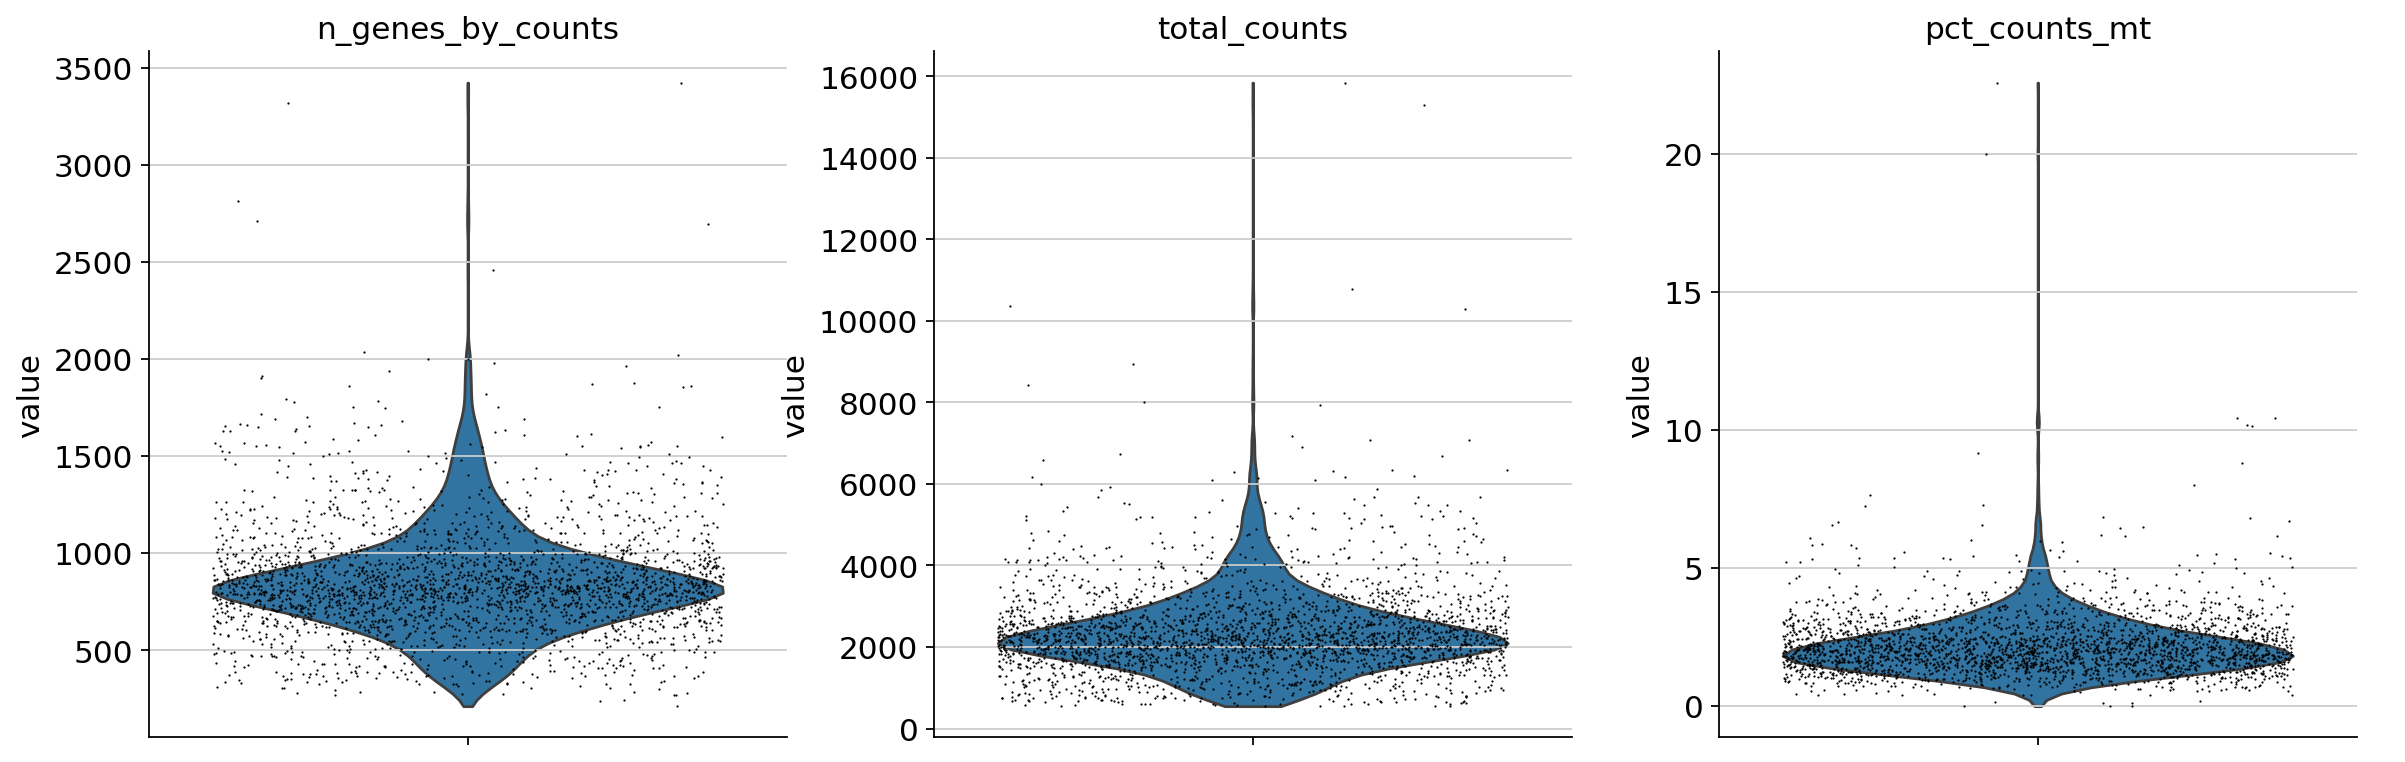

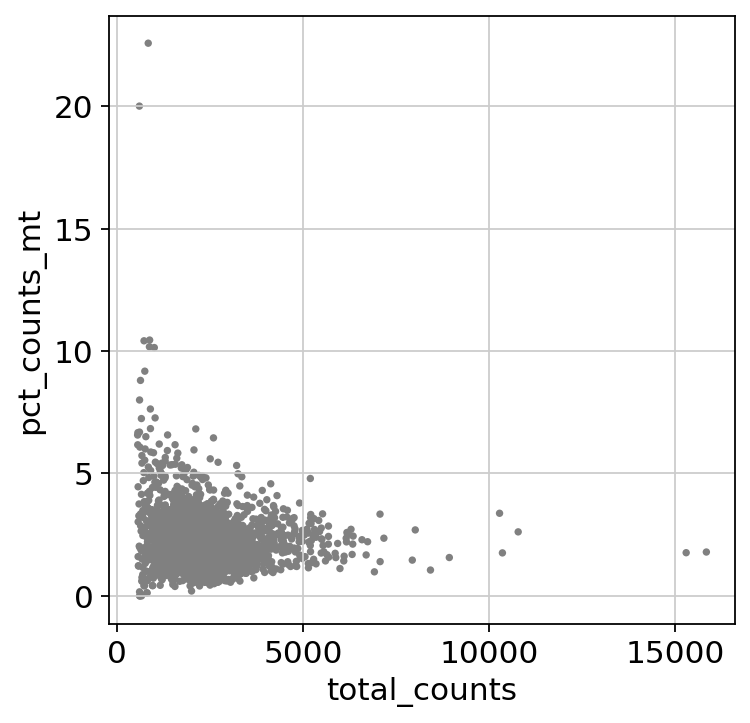

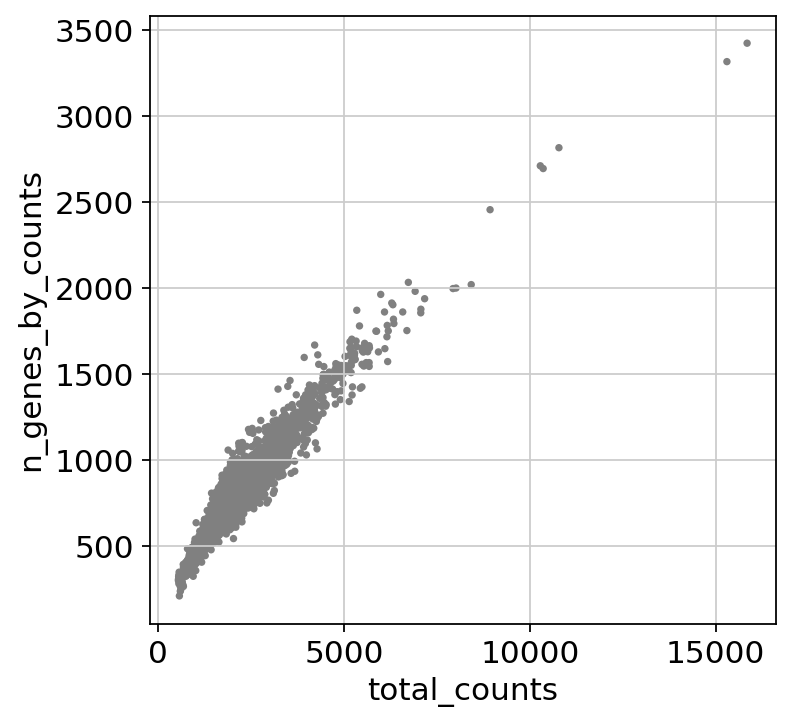

filtered out 19024 genes that are detected in less than 3 cells
Running Scrublet
filtered out 58 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.24
Detected doublet rate = 1.6%
Estimated detectable doublet fraction = 38.3%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 4.3%
    Scrublet finished (0:00:02)
Predicted doublets: 43
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boole

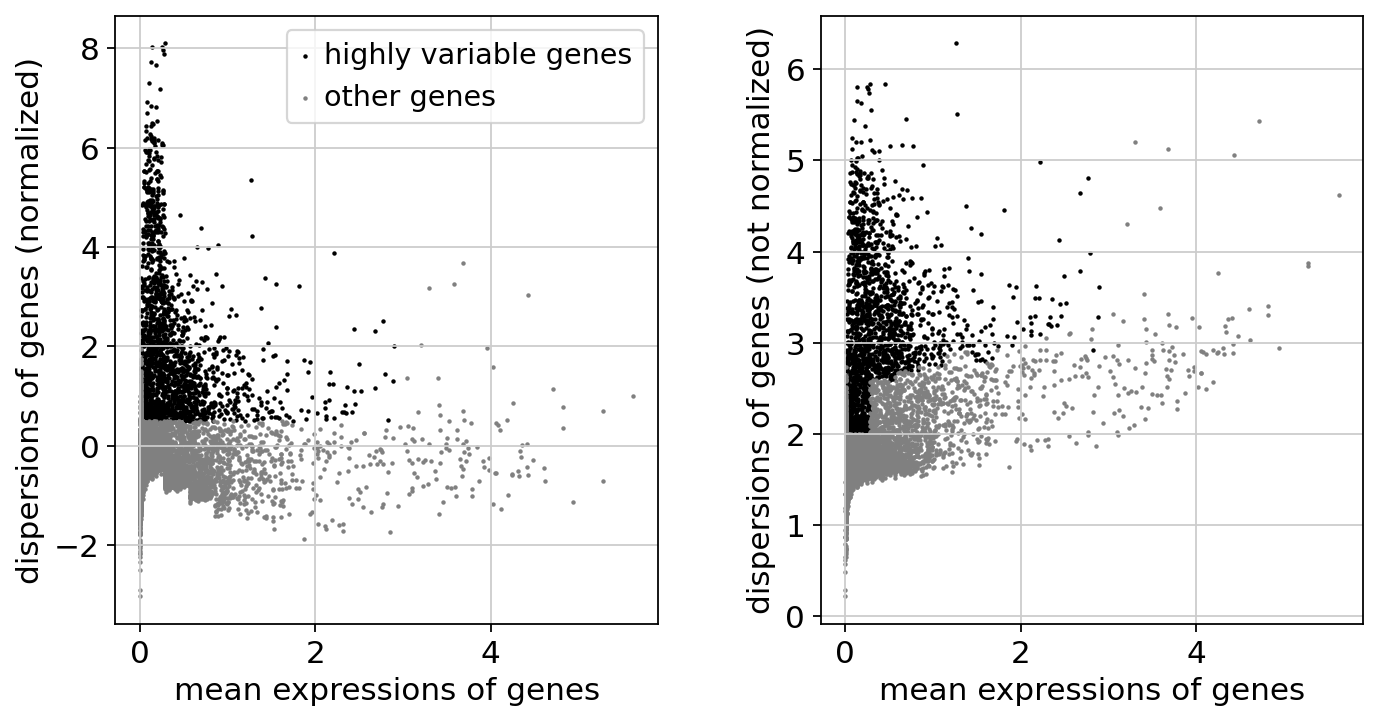

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    9 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    12 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)


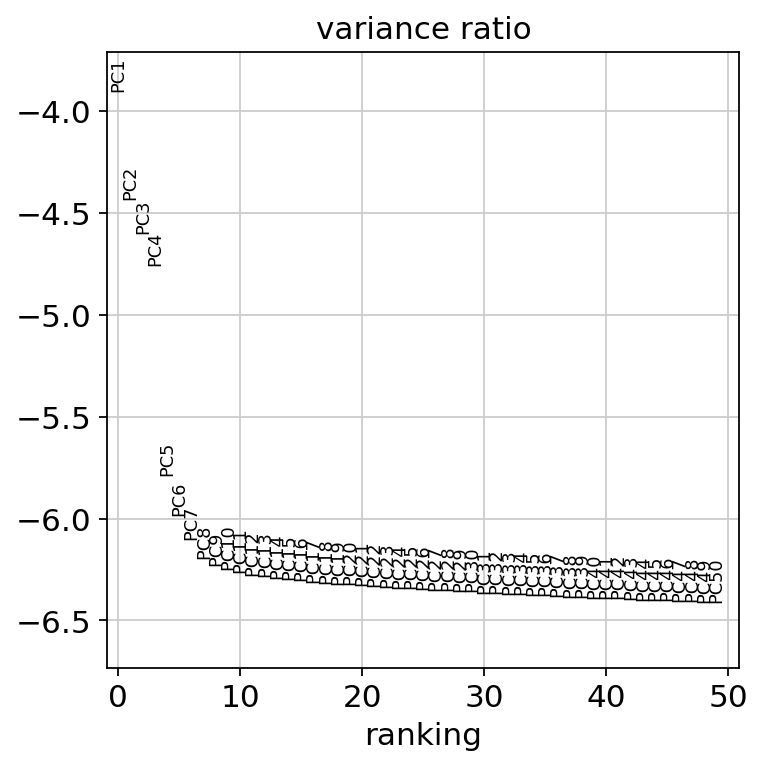

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
computing tSNE
    using 'X_pca' with n_pcs = 40
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:00:20)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


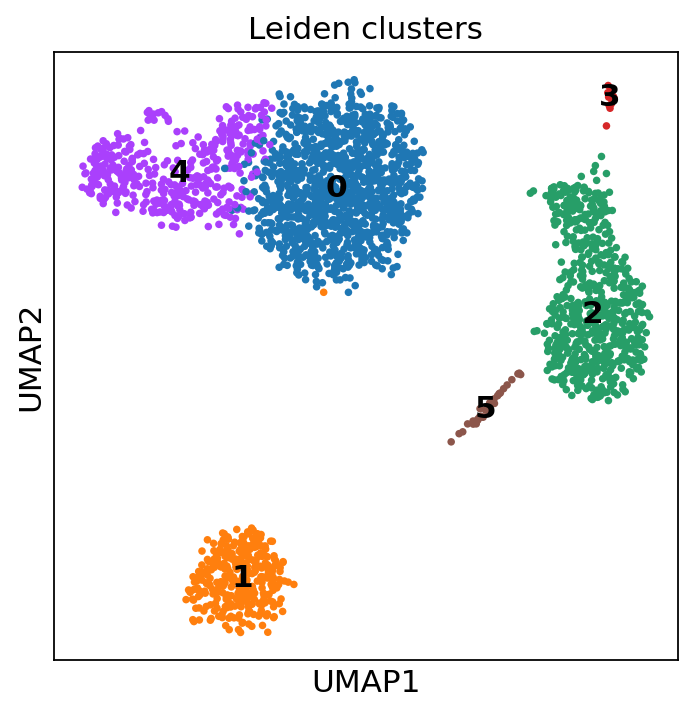

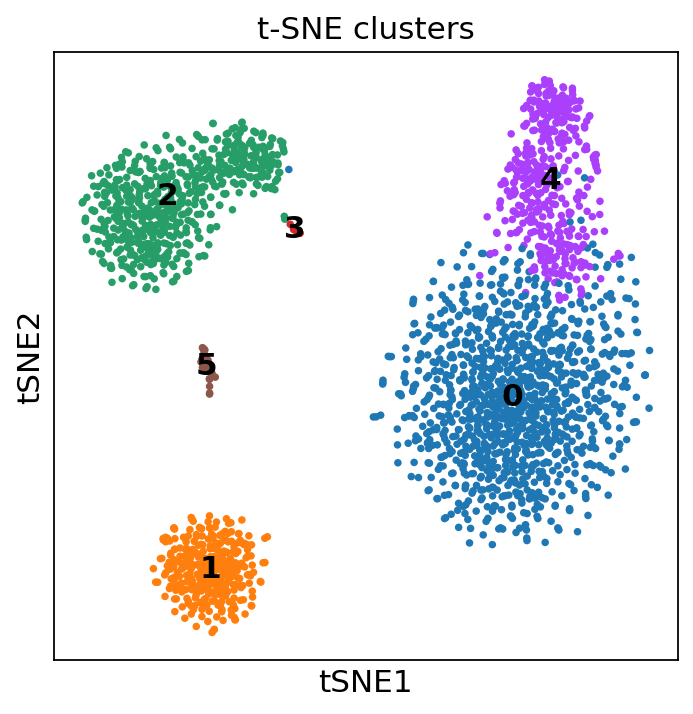

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


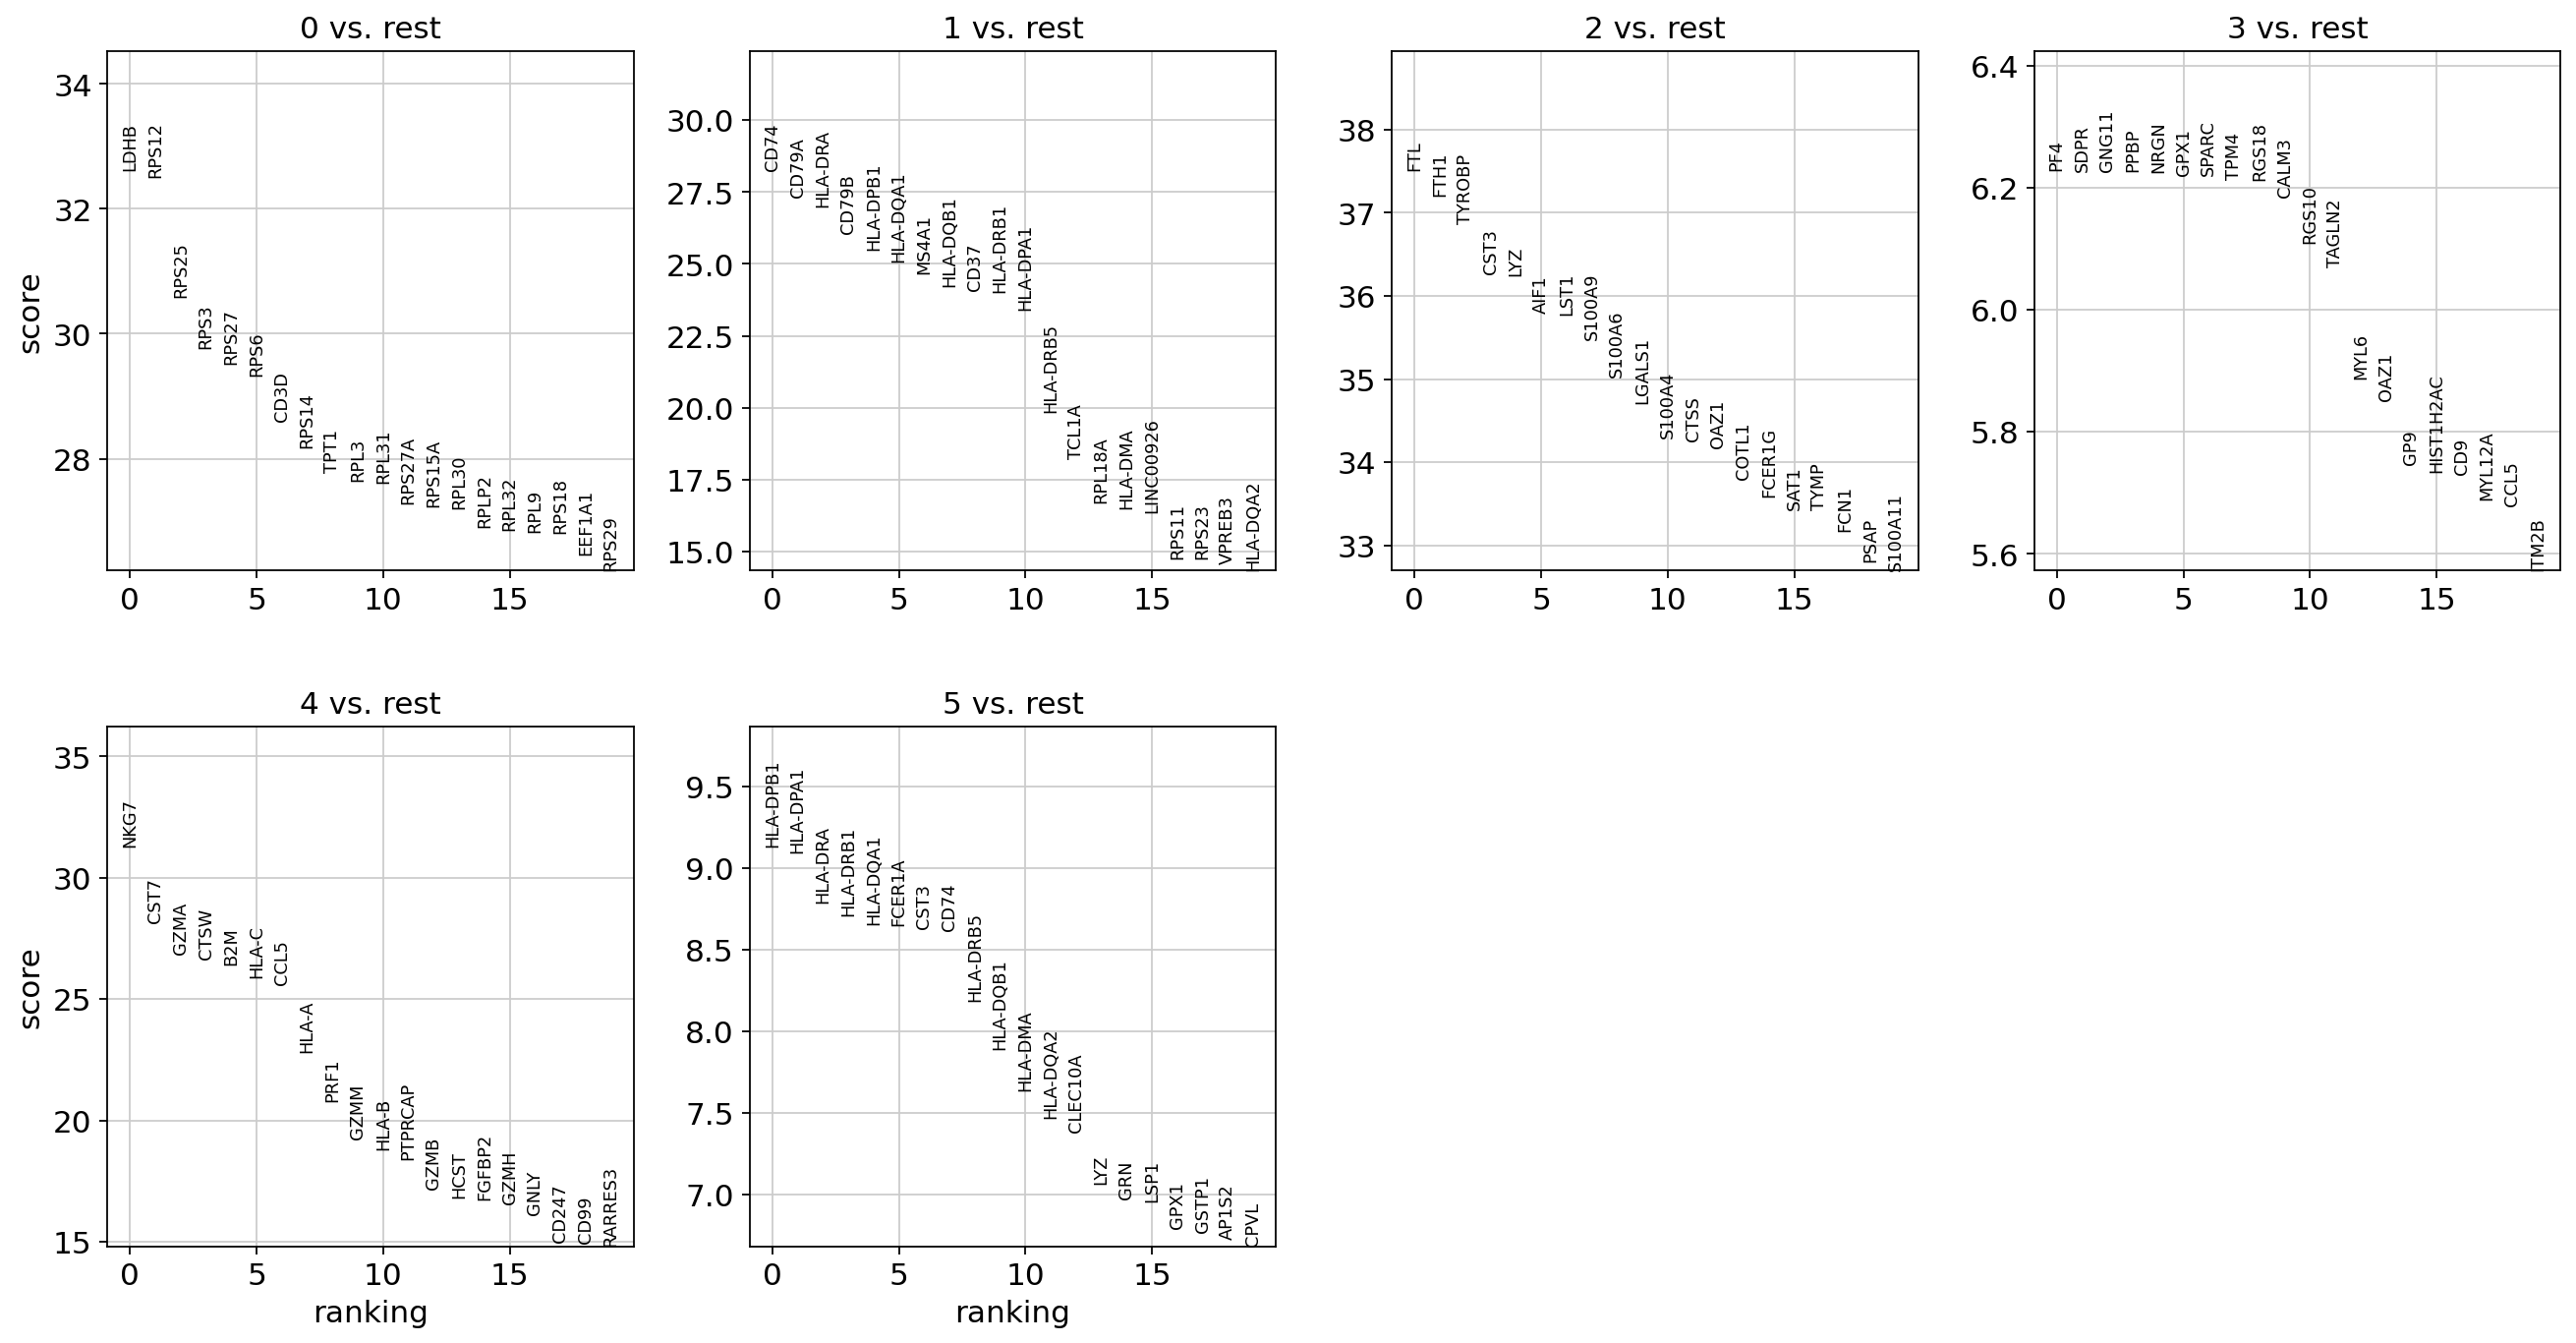


Top 10 markers per cluster:
        0         1       2      3      4         5
0   LDHB      CD74     FTL    PF4   NKG7  HLA-DPB1
1  RPS12     CD79A    FTH1   SDPR   CST7  HLA-DPA1
2  RPS25   HLA-DRA  TYROBP  GNG11   GZMA   HLA-DRA
3   RPS3     CD79B    CST3   PPBP   CTSW  HLA-DRB1
4  RPS27  HLA-DPB1     LYZ   NRGN    B2M  HLA-DQA1
5   RPS6  HLA-DQA1    AIF1   GPX1  HLA-C    FCER1A
6   CD3D     MS4A1    LST1  SPARC   CCL5      CST3
7  RPS14  HLA-DQB1  S100A9   TPM4  HLA-A      CD74
8   TPT1      CD37  S100A6  RGS18   PRF1  HLA-DRB5
9   RPL3  HLA-DRB1  LGALS1  CALM3   GZMM  HLA-DQB1


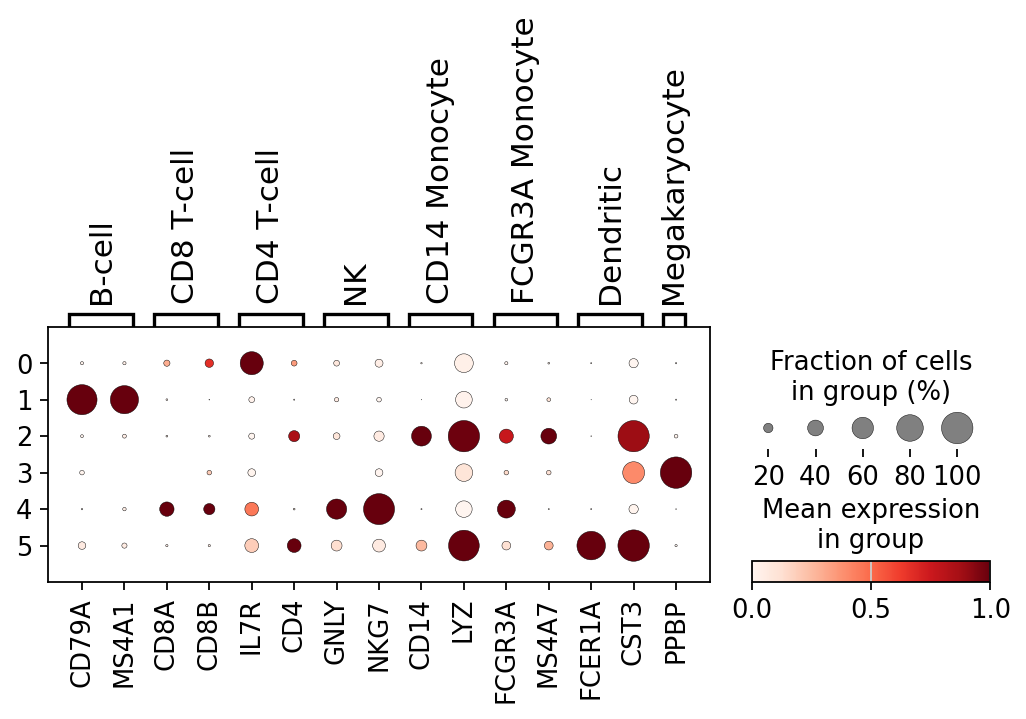

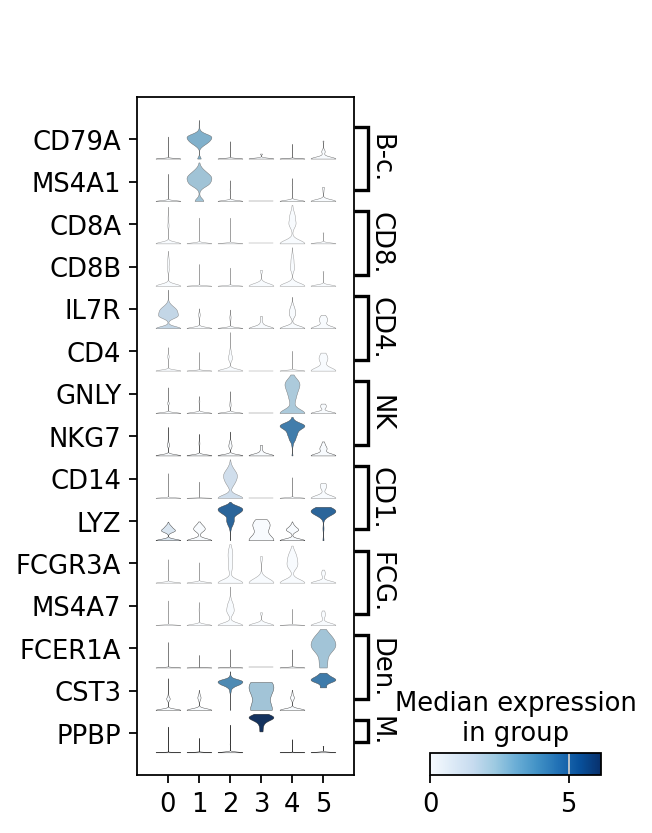

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


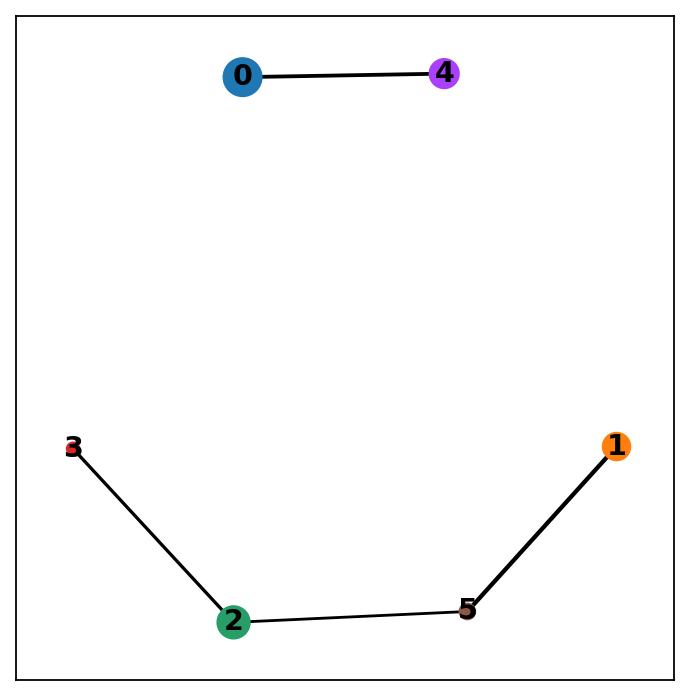

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


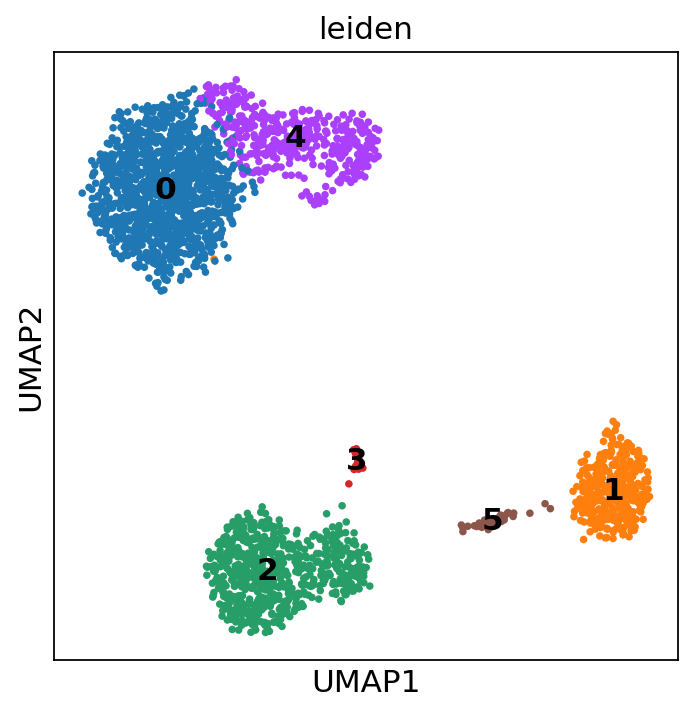

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9966717  0.99627036 0.9810964  0.9690369  0.96129274
     0.9465806  0.8708702  0.86024195 0.8594392  0.8129367  0.80507267
     0.7925985  0.78257376 0.7771149 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


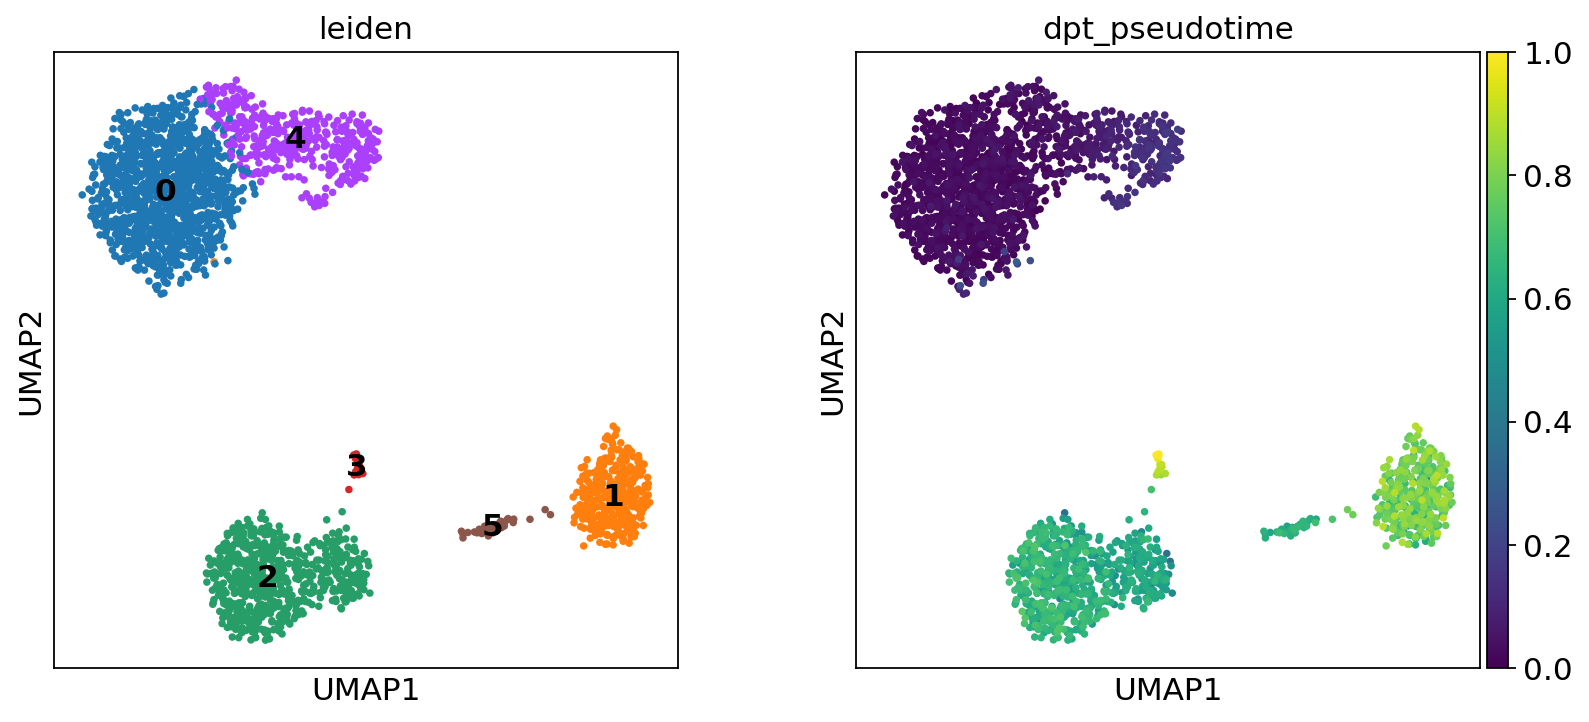

computing score 'IFN_score'
    finished: added
    'IFN_score', score of gene set (adata.obs).
    248 total control genes are used. (0:00:00)


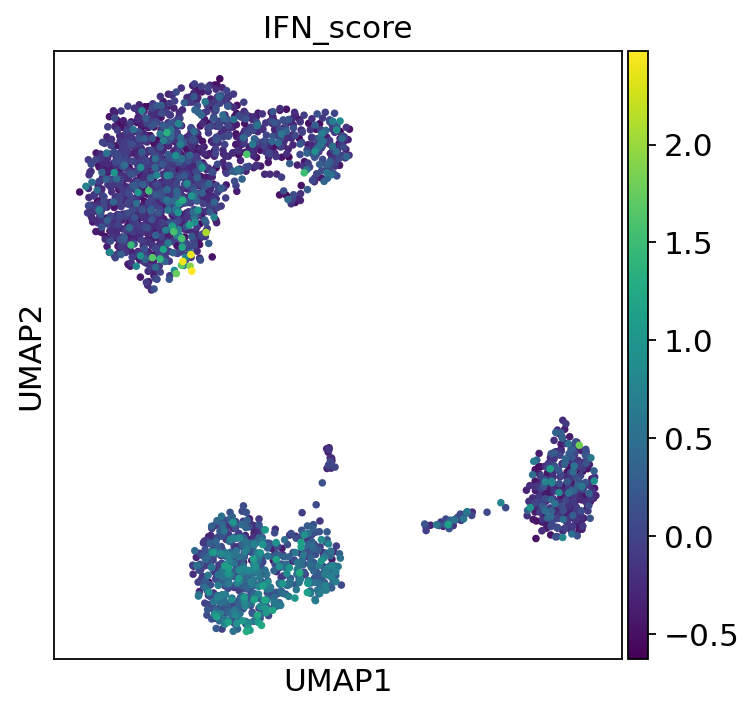


✅ Analysis complete — saved to pbmc3k_analyzed.h5ad
AnnData object with n_obs × n_vars = 2595 × 1848
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'dpt_pseudotime', 'IFN_score'
    var: 'gene_ids', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_colors', 'rank_genes_groups', 'paga', 'leiden_sizes', 'diffmap_evals', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_tsne', 'X_diffmap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


In [2]:
sc.tl.paga(adata, groups="leiden")
sc.pl.paga(adata, color="leiden", threshold=0.1)

sc.tl.umap(adata, init_pos="paga")
sc.pl.umap(adata, color="leiden", legend_loc="on data")

sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")
adata.uns["iroot"] = np.flatnonzero(adata.obs["leiden"] == adata.obs["leiden"].cat.categories[0])[0]
sc.tl.dpt(adata)
sc.pl.umap(adata, color=["leiden", "dpt_pseudotime"], legend_loc="on data")

ifn_genes = ["ISG15", "IFI6", "IFIT1", "IFIT3", "MX1", "OAS1", "STAT1", "IRF7"]
ifn_genes = [g for g in ifn_genes if g in adata.raw.var_names]
sc.tl.score_genes(adata, gene_list=ifn_genes, score_name="IFN_score")
sc.pl.umap(adata, color="IFN_score", cmap="viridis")

adata.write("pbmc3k_analyzed.h5ad")
print("\n✅ Analysis complete — saved to pbmc3k_analyzed.h5ad")
print(adata)